# Updated hybrid accDM analysis: recovered high-f q=5001 grid

This notebook constructs the current profile-likelihood map without waiting for
every high-fraction job to finish. Its selection policy is explicit:

- $f_{\rm acc}\leq0.1$: the low-f $q=1001$ campaign, with targeted $q=2501$
  recovery overriding the same coordinate when available;
- $f_{\rm acc}>0.1$: completed $q=5001$ fits from the original campaign and
  all three recovery campaigns;
- the high-f $q=1001$ scout is excluded from the physical map and used only for
  the direct momentum-resolution audit.

Pending, missing, failed, and theory-complete-but-not-yet-fitted expected points
are all marked with the same cross. Interpolation is performed separately on
the two sides of $f_{\rm acc}=0.1$, so it cannot silently smooth across the
change of CLASS momentum resolution. All quoted minima are sampled points;
interpolation is visualization only.

The final diagnostics compare both fitted $\chi^2$ and the raw one-loop theory
bundles. The latter uses the repository's canonical `compare_theories.py`
definition for `dd`, `dtheta`, and `thetatheta` over $k\leq2\,h\,{\rm Mpc}^{-1}$,
before P1D projection and nuisance optimization.

In [1]:
from pathlib import Path
import json
import os
import re
import subprocess
import sys
import warnings

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator
from scipy.stats import spearmanr


def find_project_root(start=Path.cwd()):
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "lyalpha_pt").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the lyalpha_one_loop project root.")


PROJECT_ROOT = find_project_root()
TRANSITION_LOGF = -1.0

LOW_SOURCES = [
    {
        "label": "low_q1001",
        "directory": PROJECT_ROOT / "runs/accdm/accdm_scan_lowf_q1001_v2",
        "momentum_bins": 1001,
        "priority": 10,
        "required": True,
    },
    {
        "label": "low_q2501_recovery",
        "directory": PROJECT_ROOT / "runs/accdm/accdm_lowf_recovery_q2501_10core_v1",
        "momentum_bins": 2501,
        "priority": 20,
        "required": False,
    },
]

HIGH_Q5001_SOURCES = [
    {
        "label": "high_q5001_original",
        "directory": PROJECT_ROOT / "runs/accdm/accdm_scan_highf_q5001_v1",
        "momentum_bins": 5001,
        "priority": 10,
        "required": True,
    },
    {
        "label": "high_q5001_recovery_10core",
        "directory": PROJECT_ROOT / "runs/accdm/accdm_scan_highf_q5001_recovery_10core_v1",
        "momentum_bins": 5001,
        "priority": 20,
        "required": False,
    },
    {
        "label": "high_q5001_pilot_20core",
        "directory": PROJECT_ROOT / "runs/accdm/accdm_highf_q5001_20core_pilot_v2",
        "momentum_bins": 5001,
        "priority": 30,
        "required": False,
    },
    {
        "label": "high_q5001_special_20core",
        "directory": PROJECT_ROOT / "runs/accdm/accdm_highf_q5001_20core_recovery_v2",
        "momentum_bins": 5001,
        "priority": 30,
        "required": False,
    },
]

HIGH_Q1001_DIAGNOSTIC = {
    "label": "high_q1001_scout",
    "directory": PROJECT_ROOT / "runs/accdm/accdm_scan_highf_q1001_scout_v1",
    "momentum_bins": 1001,
    "priority": 0,
    "required": True,
}

LOW_GRID_SPEC = PROJECT_ROOT / "campaigns/accdm/grid_specs/scan_lowf_boundary_q1001.json"
HIGH_GRID_SPEC = PROJECT_ROOT / "campaigns/accdm/grid_specs/scan_highf_boundary_q5001.json"
REFERENCE_FIT = PROJECT_ROOT / "results/lcdm_2022_planck_direct_k20_fit.json"
COMPARE_SCRIPT = PROJECT_ROOT / "scripts/compare_theories.py"

OUTPUT_DIR = PROJECT_ROOT / "runs/accdm/analysis_updated_hybrid_q1001_q5001_recovery_v1"
SAVE_OUTPUTS = os.environ.get("ACCDM_SAVE_OUTPUTS", "1").strip().lower() not in {
    "0", "false", "no",
}
RECOMPUTE_RAW = os.environ.get("ACCDM_RECOMPUTE_RAW", "0").strip().lower() in {
    "1", "true", "yes",
}
# 0 means every newly available overlap. Set e.g. 50 for a quick test run.
RAW_COMPARE_LIMIT = int(os.environ.get("ACCDM_RAW_COMPARE_LIMIT", "0"))
RAW_COMPARE_KMAX = 2.0

DELTA_CHI2_68_2D = 2.30
DELTA_CHI2_95_2D = 5.991
DISPLAY_DELTA_MAX = 20.0
FALLBACK_LCDM_CHI2 = 193.105787
BOUNDARY_FRACTION = 0.05
T_REFERENCE_GYR = 14.0

if REFERENCE_FIT.is_file():
    reference_payload = json.loads(REFERENCE_FIT.read_text(encoding="utf-8"))
    LCDM_ONE_LOOP_CHI2 = float(reference_payload["fits"]["one_loop"]["chi2"])
else:
    LCDM_ONE_LOOP_CHI2 = FALLBACK_LCDM_CHI2
    warnings.warn(f"Using fallback LCDM chi2={FALLBACK_LCDM_CHI2}.")

if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root          :", PROJECT_ROOT)
print("Resolution transition : log10(f_acc) =", TRANSITION_LOGF)
print("LCDM one-loop chi2    :", LCDM_ONE_LOOP_CHI2)
print("Raw comparison        : k <=", RAW_COMPARE_KMAX, "h/Mpc")
print("Output directory      :", OUTPUT_DIR)

Project root          : /home/2/ks405818/Master/lyalpha_one_loop
Resolution transition : log10(f_acc) = -1.0
LCDM one-loop chi2    : 193.19661059914853
Raw comparison        : k <= 2.0 h/Mpc
Output directory      : /home/2/ks405818/Master/lyalpha_one_loop/runs/accdm/analysis_updated_hybrid_q1001_q5001_recovery_v1


## Load campaigns and build an auditable point inventory

A fit is accepted only when both its JSON file and the corresponding
`status/fit/*.done.json` marker exist. Recovery sources have higher priority
than their original source at an identical physical coordinate. This affects
only duplicate coordinates; it never invents a new point.

In [2]:
def active_mask(frame):
    if "active" not in frame:
        return np.ones(len(frame), dtype=bool)
    return frame["active"].astype(str).str.strip().str.lower().isin({"true", "1", "yes"})


def coordinate_key(logm, logf):
    return f"{float(logm):.10f}|{float(logf):.10f}"


def fit_summary(path):
    payload = json.loads(path.read_text(encoding="utf-8"))
    fits = payload.get("fits", {})
    loop = fits.get("one_loop")
    if loop is None:
        return None
    linear = fits.get("linear")
    diagnostics = loop.get("boundary_diagnostics", [])
    nearest = None
    if diagnostics:
        nearest = min(
            diagnostics,
            key=lambda item: float(item["relative_distance_to_nearest_bound"]),
        )
    row = {
        "chi2_one_loop": float(loop["chi2"]),
        "chi2_linear": float(linear["chi2"]) if linear is not None else np.nan,
        "chi2_per_dof": float(loop.get("chi2_per_dof", np.nan)),
        "optimizer_success": bool(loop.get("optimizer_success", False)),
        "minimum_bound_distance": (
            float(nearest["relative_distance_to_nearest_bound"])
            if nearest is not None else np.nan
        ),
        "minimum_bound_parameter": nearest["parameter"] if nearest is not None else None,
    }
    row["delta_chi2_loop_minus_linear"] = (
        row["chi2_one_loop"] - row["chi2_linear"]
        if np.isfinite(row["chi2_linear"]) else np.nan
    )
    for name, value in loop.get("parameters", {}).items():
        row[f"parameter_{name}"] = float(value)
    for item in diagnostics:
        name = str(item["parameter"])
        row[f"parameter_box_width_{name}"] = float(item["upper"]) - float(item["lower"])
    return row


def load_campaign(source):
    directory = Path(source["directory"])
    manifest_path = directory / "manifest.csv"
    if not manifest_path.is_file():
        message = f"Missing campaign manifest: {manifest_path}"
        if source.get("required", False):
            raise FileNotFoundError(message)
        warnings.warn(message + " (optional recovery source skipped)")
        return pd.DataFrame()

    manifest = pd.read_csv(manifest_path)
    manifest = manifest.loc[active_mask(manifest)].copy()
    rows = []
    for record in manifest.to_dict(orient="records"):
        point_id = str(record["point_id"])
        theory_path = directory / "theory" / f"{point_id}.npz"
        fit_path = directory / "fits" / f"{point_id}.json"
        theory_done = directory / "status/theory" / f"{point_id}.done.json"
        theory_failed = directory / "status/theory" / f"{point_id}.failed.json"
        fit_done = directory / "status/fit" / f"{point_id}.done.json"
        fit_failed = directory / "status/fit" / f"{point_id}.failed.json"
        row = {
            **record,
            "coordinate_key": coordinate_key(record["log10m_acc"], record["log10f_acc"]),
            "source_label": source["label"],
            "source_directory": str(directory),
            "source_priority": int(source["priority"]),
            "momentum_bins": int(source["momentum_bins"]),
            "theory_path": str(theory_path),
            "fit_path": str(fit_path),
            "theory_complete": theory_path.is_file() and theory_done.is_file(),
            "theory_failed": theory_failed.is_file(),
            "fit_complete": fit_path.is_file() and fit_done.is_file(),
            "fit_failed": fit_failed.is_file(),
            "chi2_one_loop": np.nan,
        }
        if row["fit_complete"]:
            summary = fit_summary(fit_path)
            if summary is not None:
                row.update(summary)
        rows.append(row)
    return pd.DataFrame(rows)


ALL_SOURCES = [*LOW_SOURCES, *HIGH_Q5001_SOURCES, HIGH_Q1001_DIAGNOSTIC]
frames = [load_campaign(source) for source in ALL_SOURCES]
frames = [frame for frame in frames if not frame.empty]
all_results = pd.concat(frames, ignore_index=True, sort=False)

campaign_status = all_results.groupby("source_label").agg(
    manifest_points=("point_id", "size"),
    theory_complete=("theory_complete", "sum"),
    theory_failed=("theory_failed", "sum"),
    fit_complete=("fit_complete", "sum"),
    fit_failed=("fit_failed", "sum"),
    fitted_points=("chi2_one_loop", "count"),
)
display(campaign_status)

,manifest_points,theory_complete,theory_failed,fit_complete,fit_failed,fitted_points
source_label,,,,,,
high_q1001_scout,600,571,29,571,0,571
high_q5001_original,600,100,5,99,0,99
high_q5001_pilot_20core,1,0,1,0,0,0
high_q5001_recovery_10core,495,476,19,476,0,476
high_q5001_special_20core,4,0,4,0,0,0
low_q1001,850,843,7,843,0,843
low_q2501_recovery,8,8,0,8,0,8


## Expected grid and resolution-aware selection

The original low- and high-f campaign manifests define the expected
coordinates if a grid-spec JSON is unavailable. Missing-state categories are
reported numerically, but every non-fitted expected point receives the same
cross in figures as requested.

In [3]:
def expected_from_grid_spec_or_manifest(spec_path, fallback_directory, region_label):
    if spec_path.is_file():
        payload = json.loads(spec_path.read_text(encoding="utf-8"))
        axes = payload["axes"]
        rows = [
            {
                "coordinate_key": coordinate_key(logm, logf),
                "log10m_acc": float(logm),
                "log10f_acc": float(logf),
                "expected_region": region_label,
            }
            for logf in axes["log10f_acc"]
            for logm in axes["log10m_acc"]
        ]
        return pd.DataFrame(rows)

    manifest = pd.read_csv(Path(fallback_directory) / "manifest.csv")
    manifest = manifest.loc[active_mask(manifest)].copy()
    result = manifest[["log10m_acc", "log10f_acc"]].drop_duplicates().copy()
    result["coordinate_key"] = [
        coordinate_key(logm, logf)
        for logm, logf in zip(result["log10m_acc"], result["log10f_acc"])
    ]
    result["expected_region"] = region_label
    return result[["coordinate_key", "log10m_acc", "log10f_acc", "expected_region"]]


expected_low = expected_from_grid_spec_or_manifest(
    LOW_GRID_SPEC, LOW_SOURCES[0]["directory"], "low",
)
expected_low = expected_low.loc[expected_low["log10f_acc"] <= TRANSITION_LOGF + 1e-12]
expected_high = expected_from_grid_spec_or_manifest(
    HIGH_GRID_SPEC, HIGH_Q5001_SOURCES[0]["directory"], "high",
)
expected_high = expected_high.loc[expected_high["log10f_acc"] > TRANSITION_LOGF + 1e-12]
expected = pd.concat([expected_low, expected_high], ignore_index=True)
if expected["coordinate_key"].duplicated().any():
    raise RuntimeError("Low- and high-f expected grids overlap unexpectedly.")

low_labels = {source["label"] for source in LOW_SOURCES}
high_labels = {source["label"] for source in HIGH_Q5001_SOURCES}

low_candidates = all_results[
    all_results["source_label"].isin(low_labels)
    & (all_results["log10f_acc"] <= TRANSITION_LOGF + 1e-12)
    & np.isfinite(all_results["chi2_one_loop"])
].copy()
high_candidates = all_results[
    all_results["source_label"].isin(high_labels)
    & (all_results["log10f_acc"] > TRANSITION_LOGF + 1e-12)
    & np.isfinite(all_results["chi2_one_loop"])
].copy()


def select_highest_priority(frame):
    if frame.empty:
        return frame.copy()
    selected = (
        frame.sort_values(["coordinate_key", "source_priority", "source_label"])
        .drop_duplicates("coordinate_key", keep="last")
        .copy()
    )
    return selected


selected_low = select_highest_priority(low_candidates)
selected_high = select_highest_priority(high_candidates)
selected = pd.concat([selected_low, selected_high], ignore_index=True, sort=False)
if selected["coordinate_key"].duplicated().any():
    raise RuntimeError("A selected coordinate has more than one likelihood.")

# Aggregate stage information only to explain why an expected point is absent.
eligible_status = all_results[
    all_results["source_label"].isin(low_labels | high_labels)
].copy()
stage_by_coordinate = eligible_status.groupby("coordinate_key").agg(
    any_theory_complete=("theory_complete", "max"),
    any_theory_failed=("theory_failed", "max"),
    any_fit_complete=("fit_complete", "max"),
    any_fit_failed=("fit_failed", "max"),
).reset_index()

hybrid = expected.merge(
    selected.drop(columns=["log10m_acc", "log10f_acc"], errors="ignore"),
    on="coordinate_key", how="left", validate="one_to_one",
).merge(stage_by_coordinate, on="coordinate_key", how="left", validate="one_to_one")
for column in ["any_theory_complete", "any_theory_failed", "any_fit_complete", "any_fit_failed"]:
    hybrid[column] = hybrid[column].fillna(False).astype(bool)

completed = hybrid.loc[np.isfinite(hybrid["chi2_one_loop"])].copy()
missing = hybrid.loc[~np.isfinite(hybrid["chi2_one_loop"])].copy()

def missing_reason(row):
    if row["any_fit_failed"]:
        return "fit failed"
    if row["any_theory_complete"]:
        return "fit pending or missing"
    if row["any_theory_failed"]:
        return "theory failed"
    return "theory active, pending, or absent"

missing["missing_reason"] = missing.apply(missing_reason, axis=1)

print("Expected points :", len(expected))
print("Completed fits  :", len(completed))
print("Crosses         :", len(missing))
print("\nSelected completed fits by source")
display(completed.groupby(["source_label", "momentum_bins"]).size().rename("points").to_frame())
print("\nReasons behind the common cross marker")
display(missing["missing_reason"].value_counts().rename("points").to_frame())

Expected points : 1450
Completed fits  : 1425
Crosses         : 25

Selected completed fits by source


,,points
source_label,momentum_bins,
high_q5001_original,5001.0,99
high_q5001_recovery_10core,5001.0,476
low_q1001,1001.0,842
low_q2501_recovery,2501.0,8



Reasons behind the common cross marker


,points
missing_reason,
theory failed,24
fit pending or missing,1


## Sampled minimum, coverage, and one-loop fit improvement

The dashed horizontal line is the numerical-policy boundary. It is not a
physical feature of the accDM model.

Sampled hybrid minimum
  point_id         = accdm_logm12p7142857142857_logfm0p2
  log10(m/GeV)     = 12.71428571
  log10(f_acc)     = -0.2
  f_acc            = 0.6309573445
  chi2             = 188.429597466
  Delta chi2 LCDM  = -4.767013133
  source           = high_q5001_recovery_10core (q=5001)


,point_id,log10m_acc,log10f_acc,source_label,momentum_bins,chi2_one_loop,delta_chi2_from_hybrid_minimum,delta_chi2_vs_lcdm,minimum_bound_parameter,minimum_bound_distance
1312,accdm_logm12p7142857142857_logfm0p2,12.714286,-0.200,high_q5001_recovery_10core,5001.0,188.429597,0.000000,-4.767013,beta_ct,0.166743
1362,accdm_logm12p7142857142857_logfm0p1,12.714286,-0.100,high_q5001_recovery_10core,5001.0,188.682889,0.253292,-4.513722,beta_ct,0.186123
1262,accdm_logm12p7142857142857_logfm0p3,12.714286,-0.300,high_q5001_recovery_10core,5001.0,188.714535,0.284938,-4.482075,beta_ct,0.177740
970,accdm_logm13p8571428571429_logfm0p775,13.857143,-0.775,high_q5001_recovery_10core,5001.0,188.888373,0.458776,-4.308238,beta_ct,0.204198
1020,accdm_logm13p8571428571429_logfm0p7,13.857143,-0.700,high_q5001_recovery_10core,5001.0,188.919525,0.489928,-4.277085,alpha_bias,0.290830
633,accdm_logm15p7142857142857_logfm1p3,15.714286,-1.300,low_q1001,1001.0,188.986413,0.556815,-4.210198,beta_ct,0.267960
683,accdm_logm15p7142857142857_logfm1p225,15.714286,-1.225,low_q1001,1001.0,189.033078,0.603481,-4.163532,beta_ct,0.260682
920,accdm_logm13p8571428571429_logfm0p85,13.857143,-0.850,high_q5001_recovery_10core,5001.0,189.057679,0.628081,-4.138932,beta_ct,0.225592
634,accdm_logm15p8571428571429_logfm1p3,15.857143,-1.300,low_q1001,1001.0,189.166786,0.737188,-4.029825,beta_ct,0.260778
583,accdm_logm15p7142857142857_logfm1p375,15.714286,-1.375,low_q1001,1001.0,189.171168,0.741571,-4.025442,beta_ct,0.273742


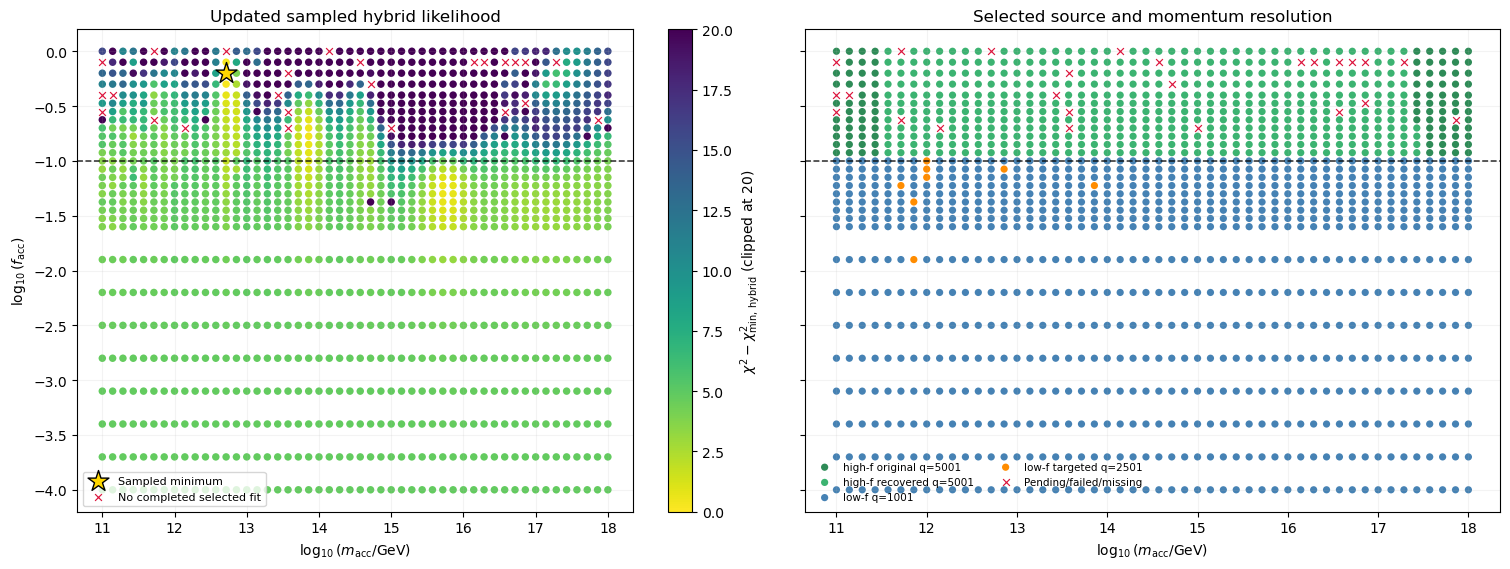

In [4]:
if completed.empty:
    raise RuntimeError("No completed selected fits are available.")

completed["delta_chi2_from_hybrid_minimum"] = (
    completed["chi2_one_loop"] - completed["chi2_one_loop"].min()
)
completed["delta_chi2_vs_lcdm"] = completed["chi2_one_loop"] - LCDM_ONE_LOOP_CHI2
completed["inside_68pct"] = completed["delta_chi2_from_hybrid_minimum"] <= DELTA_CHI2_68_2D
completed["inside_95pct"] = completed["delta_chi2_from_hybrid_minimum"] <= DELTA_CHI2_95_2D
best = completed.loc[completed["chi2_one_loop"].idxmin()]

print("Sampled hybrid minimum")
print("  point_id         =", best.get("point_id", best["coordinate_key"]))
print(f"  log10(m/GeV)     = {best['log10m_acc']:.10g}")
print(f"  log10(f_acc)     = {best['log10f_acc']:.10g}")
print(f"  f_acc            = {10**best['log10f_acc']:.10g}")
print(f"  chi2             = {best['chi2_one_loop']:.9f}")
print(f"  Delta chi2 LCDM  = {best['delta_chi2_vs_lcdm']:+.9f}")
print(f"  source           = {best['source_label']} (q={int(best['momentum_bins'])})")

columns = [
    "point_id", "log10m_acc", "log10f_acc", "source_label", "momentum_bins",
    "chi2_one_loop", "delta_chi2_from_hybrid_minimum", "delta_chi2_vs_lcdm",
    "minimum_bound_parameter", "minimum_bound_distance",
]
columns = [column for column in columns if column in completed]
display(completed.nsmallest(25, "chi2_one_loop")[columns])

fig_coverage, axes = plt.subplots(1, 2, figsize=(15.2, 5.8), sharex=True, sharey=True)
sampled = axes[0].scatter(
    completed["log10m_acc"], completed["log10f_acc"],
    c=np.clip(completed["delta_chi2_from_hybrid_minimum"], 0, DISPLAY_DELTA_MAX),
    cmap="viridis_r", s=29, edgecolor="none", rasterized=True,
)
fig_coverage.colorbar(
    sampled, ax=axes[0],
    label=r"$\chi^2-\chi^2_{\min,\,\mathrm{hybrid}}$ (clipped at 20)",
)
axes[0].scatter(
    [best["log10m_acc"]], [best["log10f_acc"]], marker="*", s=250,
    color="gold", edgecolor="black", label="Sampled minimum", zorder=7,
)
axes[0].scatter(
    missing["log10m_acc"], missing["log10f_acc"], marker="x", s=24,
    color="crimson", linewidth=0.85, label="No completed selected fit", zorder=6,
)
axes[0].set_title("Updated sampled hybrid likelihood")
axes[0].legend(frameon=True, fontsize=8)

source_styles = {
    "low_q1001": ("steelblue", "low-f q=1001"),
    "low_q2501_recovery": ("darkorange", "low-f targeted q=2501"),
    "high_q5001_original": ("seagreen", "high-f original q=5001"),
    "high_q5001_recovery_10core": ("mediumseagreen", "high-f recovered q=5001"),
    "high_q5001_pilot_20core": ("purple", "high-f q=5001 pilot"),
    "high_q5001_special_20core": ("orchid", "high-f special q=5001"),
}
for label, group in completed.groupby("source_label"):
    color, legend_label = source_styles.get(label, ("0.5", label))
    axes[1].scatter(
        group["log10m_acc"], group["log10f_acc"], s=27,
        color=color, edgecolor="none", label=legend_label, rasterized=True,
    )
axes[1].scatter(
    missing["log10m_acc"], missing["log10f_acc"], marker="x", s=24,
    color="crimson", linewidth=0.85, label="Pending/failed/missing", zorder=6,
)
axes[1].set_title("Selected source and momentum resolution")
axes[1].legend(frameon=False, fontsize=7.5, ncol=2)

for axis in axes:
    axis.axhline(TRANSITION_LOGF, color="black", ls="--", lw=1.15, alpha=0.8)
    axis.set_xlabel(r"$\log_{10}(m_{\rm acc}/{\rm GeV})$")
    axis.grid(alpha=0.14)
axes[0].set_ylabel(r"$\log_{10}(f_{\rm acc})$")
fig_coverage.tight_layout()
plt.show()

## Region-separated interpolation and profile-likelihood maps

Low-f and high-f interpolators are built independently. Consequently, a white
strip may appear between the last low-f row and the first high-f row. That is
preferable to drawing a numerically unsupported bridge across the resolution
change. The conservative panel also masks the nearest missing expected cell;
the edge-bracketed panel hatches such visual-only interpolation.

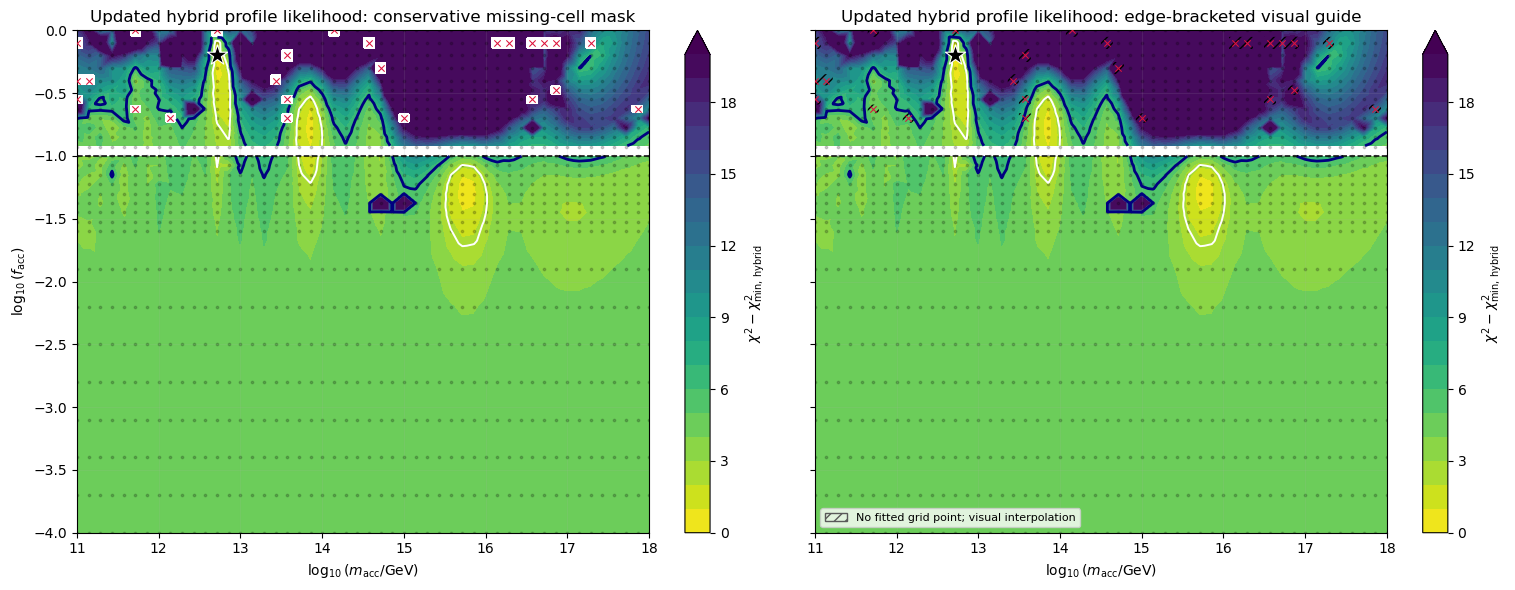

In [5]:
def composite_interpolated_surfaces(column, nx=720, ny=580):
    x_dense = np.linspace(expected["log10m_acc"].min(), expected["log10m_acc"].max(), nx)
    y_dense = np.linspace(expected["log10f_acc"].min(), expected["log10f_acc"].max(), ny)
    xx, yy = np.meshgrid(x_dense, y_dense)
    x_scale = float(np.ptp(expected["log10m_acc"]))
    y_scale = float(np.ptp(expected["log10f_acc"]))
    dense_coordinates = np.column_stack([xx.ravel() / x_scale, yy.ravel() / y_scale])

    raw = np.full(xx.shape, np.nan, dtype=float)
    nearest_available = np.zeros(xx.shape, dtype=float)

    for region, dense_region_mask in [
        ("low", yy <= TRANSITION_LOGF + 1e-12),
        ("high", yy > TRANSITION_LOGF + 1e-12),
    ]:
        sampled_region = completed.loc[completed["expected_region"] == region]
        expected_region = hybrid.loc[hybrid["expected_region"] == region]
        if len(sampled_region) < 3:
            continue

        sampled_coordinates = np.column_stack([
            sampled_region["log10m_acc"] / x_scale,
            sampled_region["log10f_acc"] / y_scale,
        ])
        interpolator = LinearNDInterpolator(
            sampled_coordinates,
            sampled_region[column].to_numpy(dtype=float),
            fill_value=np.nan,
        )
        region_raw = interpolator(dense_coordinates).reshape(xx.shape)

        expected_coordinates = np.column_stack([
            expected_region["log10m_acc"] / x_scale,
            expected_region["log10f_acc"] / y_scale,
        ])
        availability = np.isfinite(expected_region["chi2_one_loop"]).astype(float)
        region_nearest = NearestNDInterpolator(
            expected_coordinates, availability.to_numpy(dtype=float),
        )(dense_coordinates).reshape(xx.shape)

        raw[dense_region_mask] = region_raw[dense_region_mask]
        nearest_available[dense_region_mask] = region_nearest[dense_region_mask]

    finite = np.isfinite(raw)
    conservative = np.ma.array(raw, mask=(~finite) | (nearest_available < 0.5))
    bracketed = np.ma.array(raw, mask=~finite)
    unsupported = finite & (nearest_available < 0.5)
    return x_dense, y_dense, conservative, bracketed, unsupported


x_dense, y_dense, delta_min_conservative, delta_min_bracketed, unsupported = (
    composite_interpolated_surfaces("delta_chi2_from_hybrid_minimum")
)
_, _, delta_lcdm_conservative, delta_lcdm_bracketed, unsupported_lcdm = (
    composite_interpolated_surfaces("delta_chi2_vs_lcdm")
)


def draw_profile_pair(x, y, conservative, bracketed, unsupported_mask, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(15.5, 6.0), sharex=True, sharey=True)
    for index, (axis, surface, title) in enumerate(zip(
        axes,
        [conservative, bracketed],
        ["conservative missing-cell mask", "edge-bracketed visual guide"],
    )):
        plotted = axis.contourf(
            x, y, np.clip(surface, 0, DISPLAY_DELTA_MAX),
            levels=np.linspace(0, DISPLAY_DELTA_MAX, 21),
            cmap="viridis_r", extend="max",
        )
        if np.nanmin(surface.filled(np.nan)) <= DELTA_CHI2_68_2D <= np.nanmax(surface.filled(np.nan)):
            axis.contour(
                x, y, surface, levels=[DELTA_CHI2_68_2D, DELTA_CHI2_95_2D],
                colors=["white", "navy"], linewidths=[1.4, 2.0],
            )
        axis.scatter(
            completed["log10m_acc"], completed["log10f_acc"],
            s=3, color="black", alpha=0.18, rasterized=True,
        )
        axis.scatter(
            missing["log10m_acc"], missing["log10f_acc"], marker="x", s=21,
            color="crimson", linewidth=0.75, zorder=6,
        )
        axis.scatter(
            [best["log10m_acc"]], [best["log10f_acc"]], marker="*", s=235,
            color="black", edgecolor="white", linewidth=0.8, zorder=7,
        )
        axis.axhline(TRANSITION_LOGF, color="black", ls="--", lw=1.1)
        if index == 1 and np.any(unsupported_mask):
            axis.contourf(
                x, y, unsupported_mask.astype(float), levels=[0.5, 1.5],
                colors="none", hatches=["///"], alpha=0,
            )
        axis.set_title(f"{title_prefix}: {title}")
        axis.set_xlabel(r"$\log_{10}(m_{\rm acc}/{\rm GeV})$")
        axis.grid(alpha=0.12)
        fig.colorbar(plotted, ax=axis, label=r"$\chi^2-\chi^2_{\min,\,\mathrm{hybrid}}$")
    axes[0].set_ylabel(r"$\log_{10}(f_{\rm acc})$")
    axes[1].legend(
        handles=[
            Patch(facecolor="none", edgecolor="0.35", hatch="///",
                  label="No fitted grid point; visual interpolation"),
        ],
        loc="best", frameon=True, fontsize=8,
    )
    fig.tight_layout()
    return fig


fig_profile = draw_profile_pair(
    x_dense, y_dense, delta_min_conservative, delta_min_bracketed,
    unsupported, "Updated hybrid profile likelihood",
)
plt.show()

## Direct fitted $\chi^2$ comparison: high-f q=1001 versus q=5001

This overlap is diagnostic only. The physical hybrid map continues to use
high-f $q=5001$. Two shifts are shown:

- absolute shift: $\chi^2_{5001}-\chi^2_{1001}$;
- subset-normalized shape shift: each overlap sample has its own minimum
  subtracted first. The latter is the more relevant warning for contour
  deformation, while the former also contains a nearly constant offset.

,value
overlap points,546.000000
mean signed chi2 shift,-1.822875
median signed chi2 shift,-0.309713
RMS chi2 shift,9.883611
maximum |chi2 shift|,126.157650
RMS shape shift,10.388397
maximum |shape shift|,128.016610
Spearman rank correlation,0.937351
changed 68% classifications,23.000000
changed 95% classifications,84.000000


,point_id_q1001,point_id_q5001,log10m_acc,log10f_acc,chi2_one_loop_q1001,chi2_one_loop_q5001,delta_chi2_q5001_minus_q1001,shape_shift_q5001_minus_q1001,classification_changed_68pct,classification_changed_95pct
420,accdm_logm16p2857142857143_logfm0p2,accdm_logm16p2857142857143_logfm0p2,16.285714,-0.200,428.839172,302.681522,-126.157650,-128.016610,False,False
409,accdm_logm16p1428571428571_logfm0p3,accdm_logm16p1428571428571_logfm0p3,16.142857,-0.300,360.800116,450.467397,89.667281,87.808321,False,False
439,accdm_logm16p5714285714286_logfm0p3,accdm_logm16p5714285714286_logfm0p3,16.571429,-0.300,253.289450,203.088938,-50.200512,-52.059472,False,False
94,accdm_logm12p1428571428571_logf0,accdm_logm12p1428571428571_logf0,12.142857,0.000,242.492693,200.421842,-42.070851,-43.929811,False,False
262,accdm_logm14p2857142857143_logfm0p1,accdm_logm14p2857142857143_logfm0p1,14.285714,-0.100,256.259726,218.801146,-37.458581,-39.317540,False,False
71,accdm_logm11p8571428571429_logf0,accdm_logm11p8571428571429_logf0,11.857143,0.000,245.008296,211.287536,-33.720760,-35.579720,False,False
449,accdm_logm16p7142857142857_logfm0p3,accdm_logm16p7142857142857_logfm0p3,16.714286,-0.300,236.999149,204.492440,-32.506709,-34.365669,False,False
81,accdm_logm12_logfm0p2,accdm_logm12_logfm0p2,12.000000,-0.200,230.231196,199.315413,-30.915783,-32.774743,False,False
52,accdm_logm11p5714285714286_logf0,accdm_logm11p5714285714286_logf0,11.571429,0.000,253.890747,223.373201,-30.517546,-32.376506,False,False
229,accdm_logm13p8571428571429_logf0,accdm_logm13p8571428571429_logf0,13.857143,0.000,258.277354,227.772093,-30.505262,-32.364222,False,False


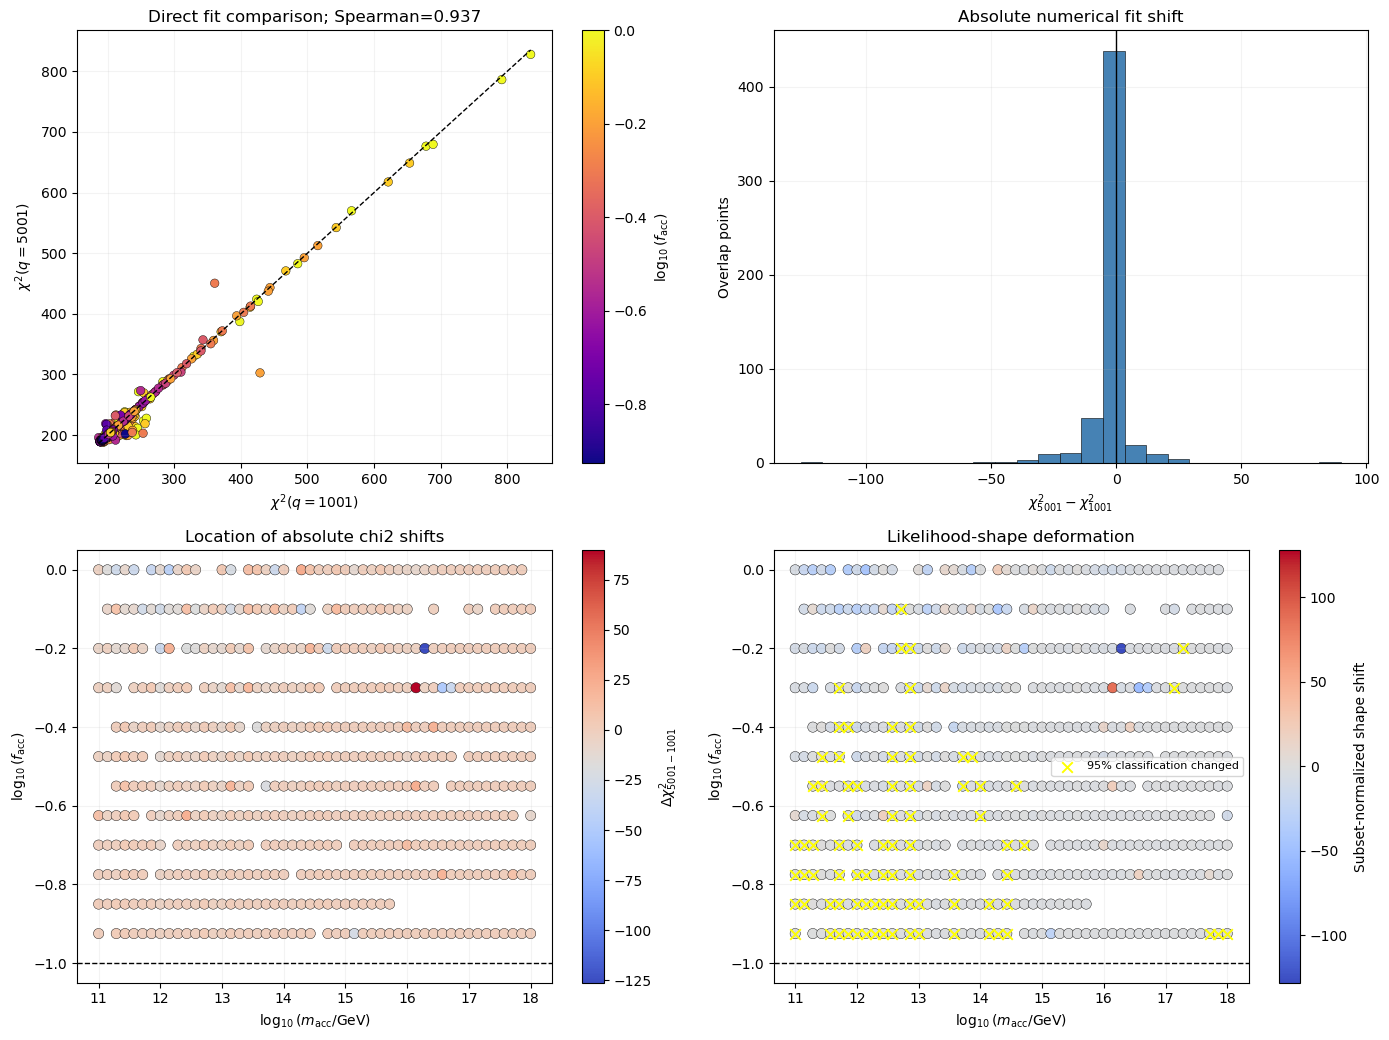

In [6]:
q1001_fit = all_results[
    (all_results["source_label"] == HIGH_Q1001_DIAGNOSTIC["label"])
    & np.isfinite(all_results["chi2_one_loop"])
].copy()
q5001_fit = selected_high.copy()

overlap = q1001_fit.merge(
    q5001_fit, on="coordinate_key", how="inner",
    suffixes=("_q1001", "_q5001"), validate="one_to_one",
)
if overlap.empty:
    warnings.warn("No completed q=1001/q=5001 fit overlap is available yet.")
else:
    overlap["log10m_acc"] = overlap["log10m_acc_q1001"]
    overlap["log10f_acc"] = overlap["log10f_acc_q1001"]
    overlap["delta_chi2_q5001_minus_q1001"] = (
        overlap["chi2_one_loop_q5001"] - overlap["chi2_one_loop_q1001"]
    )
    overlap["relative_chi2_q1001"] = (
        overlap["chi2_one_loop_q1001"] - overlap["chi2_one_loop_q1001"].min()
    )
    overlap["relative_chi2_q5001"] = (
        overlap["chi2_one_loop_q5001"] - overlap["chi2_one_loop_q5001"].min()
    )
    overlap["shape_shift_q5001_minus_q1001"] = (
        overlap["relative_chi2_q5001"] - overlap["relative_chi2_q1001"]
    )
    overlap["absolute_chi2_shift"] = overlap["delta_chi2_q5001_minus_q1001"].abs()
    overlap["absolute_shape_shift"] = overlap["shape_shift_q5001_minus_q1001"].abs()
    for threshold, label in [(DELTA_CHI2_68_2D, "68pct"), (DELTA_CHI2_95_2D, "95pct")]:
        overlap[f"inside_{label}_q1001"] = overlap["relative_chi2_q1001"] <= threshold
        overlap[f"inside_{label}_q5001"] = overlap["relative_chi2_q5001"] <= threshold
        overlap[f"classification_changed_{label}"] = (
            overlap[f"inside_{label}_q1001"] != overlap[f"inside_{label}_q5001"]
        )

    rank = spearmanr(overlap["chi2_one_loop_q1001"], overlap["chi2_one_loop_q5001"])
    shift = overlap["delta_chi2_q5001_minus_q1001"]
    shape_shift = overlap["shape_shift_q5001_minus_q1001"]
    overlap_summary = pd.Series({
        "overlap points": len(overlap),
        "mean signed chi2 shift": float(shift.mean()),
        "median signed chi2 shift": float(shift.median()),
        "RMS chi2 shift": float(np.sqrt(np.mean(shift**2))),
        "maximum |chi2 shift|": float(shift.abs().max()),
        "RMS shape shift": float(np.sqrt(np.mean(shape_shift**2))),
        "maximum |shape shift|": float(shape_shift.abs().max()),
        "Spearman rank correlation": float(rank.statistic),
        "changed 68% classifications": int(overlap["classification_changed_68pct"].sum()),
        "changed 95% classifications": int(overlap["classification_changed_95pct"].sum()),
    })
    display(overlap_summary.to_frame("value"))
    display(overlap.sort_values("absolute_shape_shift", ascending=False)[[
        "point_id_q1001", "point_id_q5001", "log10m_acc", "log10f_acc",
        "chi2_one_loop_q1001", "chi2_one_loop_q5001",
        "delta_chi2_q5001_minus_q1001", "shape_shift_q5001_minus_q1001",
        "classification_changed_68pct", "classification_changed_95pct",
    ]].head(30))

    fig_chi2, axes = plt.subplots(2, 2, figsize=(14.0, 10.5))
    scatter = axes[0, 0].scatter(
        overlap["chi2_one_loop_q1001"], overlap["chi2_one_loop_q5001"],
        c=overlap["log10f_acc"], cmap="plasma", s=38,
        edgecolor="black", linewidth=0.3,
    )
    lower = float(min(overlap["chi2_one_loop_q1001"].min(), overlap["chi2_one_loop_q5001"].min()))
    upper = float(max(overlap["chi2_one_loop_q1001"].max(), overlap["chi2_one_loop_q5001"].max()))
    axes[0, 0].plot([lower, upper], [lower, upper], color="black", ls="--", lw=1)
    fig_chi2.colorbar(scatter, ax=axes[0, 0], label=r"$\log_{10}(f_{\rm acc})$")
    axes[0, 0].set_xlabel(r"$\chi^2(q=1001)$")
    axes[0, 0].set_ylabel(r"$\chi^2(q=5001)$")
    axes[0, 0].set_title(f"Direct fit comparison; Spearman={rank.statistic:.3f}")

    axes[0, 1].hist(shift, bins=25, color="steelblue", edgecolor="black", linewidth=0.4)
    axes[0, 1].axvline(0, color="black", lw=1)
    axes[0, 1].set_xlabel(r"$\chi^2_{5001}-\chi^2_{1001}$")
    axes[0, 1].set_ylabel("Overlap points")
    axes[0, 1].set_title("Absolute numerical fit shift")

    absolute_map = axes[1, 0].scatter(
        overlap["log10m_acc"], overlap["log10f_acc"],
        c=shift, cmap="coolwarm", s=55, edgecolor="black", linewidth=0.3,
    )
    fig_chi2.colorbar(absolute_map, ax=axes[1, 0], label=r"$\Delta\chi^2_{5001-1001}$")
    axes[1, 0].set_title("Location of absolute chi2 shifts")

    shape_limit = max(float(shape_shift.abs().max()), 1e-12)
    shape_map = axes[1, 1].scatter(
        overlap["log10m_acc"], overlap["log10f_acc"],
        c=shape_shift, cmap="coolwarm", vmin=-shape_limit, vmax=shape_limit,
        s=55, edgecolor="black", linewidth=0.3,
    )
    fig_chi2.colorbar(shape_map, ax=axes[1, 1], label="Subset-normalized shape shift")
    changed = overlap.loc[overlap["classification_changed_95pct"]]
    axes[1, 1].scatter(
        changed["log10m_acc"], changed["log10f_acc"], marker="x", s=58,
        color="yellow", linewidth=1.4, label="95% classification changed",
    )
    axes[1, 1].set_title("Likelihood-shape deformation")
    if not changed.empty:
        axes[1, 1].legend(frameon=True, fontsize=8)
    for axis in axes[1, :]:
        axis.axhline(TRANSITION_LOGF, color="black", ls="--", lw=1)
        axis.set_xlabel(r"$\log_{10}(m_{\rm acc}/{\rm GeV})$")
        axis.set_ylabel(r"$\log_{10}(f_{\rm acc})$")
    for axis in axes.ravel():
        axis.grid(alpha=0.15)
    fig_chi2.tight_layout()
    plt.show()

## Raw one-loop theory comparison before fitting

For every coordinate with both a completed high-f $q=1001$ and $q=5001$
theory bundle, the cell below runs `scripts/compare_theories.py` and parses all
21 channel/redshift rows. It records:

- the largest `max_abs` over all redshifts and `dd/dtheta/thetatheta` channels;
- the largest and median RMS difference;
- the redshift and channel responsible for the largest deviation.

The cache is incremental and includes file size and modification time in its
signature. Re-running the notebook after more jobs finish therefore processes
only new or replaced theory files. Set `ACCDM_RAW_COMPARE_LIMIT=50` before
starting Jupyter for a short test; the default `0` analyzes every new overlap.

In [7]:
def select_theory_highest_priority(frame):
    available = frame.loc[frame["theory_complete"]].copy()
    if available.empty:
        return available
    return (
        available.sort_values(["coordinate_key", "source_priority", "source_label"])
        .drop_duplicates("coordinate_key", keep="last")
        .copy()
    )


q1001_theory = select_theory_highest_priority(
    all_results.loc[all_results["source_label"] == HIGH_Q1001_DIAGNOSTIC["label"]]
)
q5001_theory = select_theory_highest_priority(
    all_results.loc[all_results["source_label"].isin(high_labels)]
)
raw_pairs = q1001_theory.merge(
    q5001_theory, on="coordinate_key", how="inner",
    suffixes=("_q1001", "_q5001"), validate="one_to_one",
)
raw_pairs["log10m_acc"] = raw_pairs["log10m_acc_q1001"]
raw_pairs["log10f_acc"] = raw_pairs["log10f_acc_q1001"]


def file_signature(path):
    path = Path(path)
    stat = path.stat()
    return f"{path.resolve()}|{stat.st_size}|{stat.st_mtime_ns}"


raw_pairs["comparison_signature"] = [
    file_signature(left) + "||" + file_signature(right)
    for left, right in zip(raw_pairs["theory_path_q1001"], raw_pairs["theory_path_q5001"])
]

RAW_SUMMARY_CACHE = OUTPUT_DIR / "raw_q1001_q5001_theory_overlap.csv"
RAW_CHANNEL_CACHE = OUTPUT_DIR / "raw_q1001_q5001_theory_channels.csv"
RAW_ERROR_CACHE = OUTPUT_DIR / "raw_q1001_q5001_theory_errors.csv"

if not COMPARE_SCRIPT.is_file():
    raise FileNotFoundError(f"Missing canonical comparison script: {COMPARE_SCRIPT}")

if RAW_SUMMARY_CACHE.is_file() and not RECOMPUTE_RAW:
    cached_summary = pd.read_csv(RAW_SUMMARY_CACHE)
else:
    cached_summary = pd.DataFrame()
if RAW_CHANNEL_CACHE.is_file() and not RECOMPUTE_RAW:
    cached_channels = pd.read_csv(RAW_CHANNEL_CACHE)
else:
    cached_channels = pd.DataFrame()

current_signatures = set(raw_pairs["comparison_signature"])
if not cached_summary.empty:
    cached_summary = cached_summary.loc[
        cached_summary["comparison_signature"].isin(current_signatures)
    ].copy()
done_signatures = set(cached_summary.get("comparison_signature", pd.Series(dtype=str)))
todo = raw_pairs.loc[~raw_pairs["comparison_signature"].isin(done_signatures)].copy()
if RAW_COMPARE_LIMIT > 0:
    todo = todo.head(RAW_COMPARE_LIMIT)

LINE_PATTERN = re.compile(
    r"^z=(?P<z>[-+0-9.eE]+)\s+"
    r"(?P<channel>dd|dtheta|thetatheta)\s+"
    r"max_abs=(?P<max_abs>[-+0-9.eE]+)\s+"
    r"rms=(?P<rms>[-+0-9.eE]+)$"
)


def compare_raw_pair(record):
    command = [
        sys.executable, str(COMPARE_SCRIPT),
        str(record["theory_path_q1001"]), str(record["theory_path_q5001"]),
        "--k-max", str(RAW_COMPARE_KMAX),
    ]
    process = subprocess.run(
        command, cwd=PROJECT_ROOT, text=True,
        capture_output=True, check=False,
    )
    if process.returncode != 0:
        raise RuntimeError((process.stderr or process.stdout).strip())
    channel_rows = []
    for line in process.stdout.splitlines():
        match = LINE_PATTERN.match(line.strip())
        if match:
            item = match.groupdict()
            channel_rows.append({
                "comparison_signature": record["comparison_signature"],
                "coordinate_key": record["coordinate_key"],
                "log10m_acc": float(record["log10m_acc"]),
                "log10f_acc": float(record["log10f_acc"]),
                "z": float(item["z"]),
                "channel": item["channel"],
                "max_abs": float(item["max_abs"]),
                "rms": float(item["rms"]),
            })
    if not channel_rows:
        raise RuntimeError("No channel rows recognized in compare_theories.py output.")
    channels = pd.DataFrame(channel_rows)
    worst = channels.loc[channels["max_abs"].idxmax()]
    summary = {
        "comparison_signature": record["comparison_signature"],
        "coordinate_key": record["coordinate_key"],
        "point_id_q1001": record["point_id_q1001"],
        "point_id_q5001": record["point_id_q5001"],
        "source_label_q5001": record["source_label_q5001"],
        "theory_path_q1001": record["theory_path_q1001"],
        "theory_path_q5001": record["theory_path_q5001"],
        "log10m_acc": float(record["log10m_acc"]),
        "log10f_acc": float(record["log10f_acc"]),
        "raw_max_abs": float(channels["max_abs"].max()),
        "raw_rms_max": float(channels["rms"].max()),
        "raw_rms_median": float(channels["rms"].median()),
        "worst_z": float(worst["z"]),
        "worst_channel": str(worst["channel"]),
        "channel_rows": int(len(channels)),
    }
    return summary, channel_rows


new_summaries = []
new_channels = []
raw_errors = []
print(f"Raw theory pairs available: {len(raw_pairs)}")
print(f"Cached and current         : {len(done_signatures)}")
print(f"New pairs in this run      : {len(todo)}")
for number, record in enumerate(todo.to_dict(orient="records"), start=1):
    try:
        summary, channels = compare_raw_pair(record)
        new_summaries.append(summary)
        new_channels.extend(channels)
    except Exception as error:
        raw_errors.append({
            "coordinate_key": record["coordinate_key"],
            "log10m_acc": record["log10m_acc"],
            "log10f_acc": record["log10f_acc"],
            "comparison_signature": record["comparison_signature"],
            "error": str(error),
        })
    if number % 25 == 0 or number == len(todo):
        print(f"  processed {number}/{len(todo)} new pairs")

summary_parts = [
    frame for frame in [cached_summary, pd.DataFrame(new_summaries)]
    if not frame.empty
]
if summary_parts:
    raw_summary = pd.concat(
        summary_parts, ignore_index=True, sort=False,
    ).drop_duplicates("comparison_signature", keep="last")
else:
    raw_summary = pd.DataFrame(columns=[
        "comparison_signature", "coordinate_key", "log10m_acc", "log10f_acc",
        "raw_max_abs", "raw_rms_max", "raw_rms_median", "worst_z", "worst_channel",
    ])
raw_channels = pd.concat(
    [cached_channels, pd.DataFrame(new_channels)], ignore_index=True, sort=False,
)
if not raw_channels.empty:
    raw_channels = raw_channels.loc[
        raw_channels["comparison_signature"].isin(set(raw_summary["comparison_signature"]))
    ].drop_duplicates(["comparison_signature", "z", "channel"], keep="last")

if SAVE_OUTPUTS:
    raw_summary.to_csv(RAW_SUMMARY_CACHE, index=False)
    raw_channels.to_csv(RAW_CHANNEL_CACHE, index=False)
    if raw_errors:
        pd.DataFrame(raw_errors).to_csv(RAW_ERROR_CACHE, index=False)

if raw_summary.empty:
    warnings.warn("No raw q=1001/q=5001 theory comparisons are available.")
else:
    raw_overview = pd.Series({
        "compared theory points": len(raw_summary),
        "median worst-channel max_abs": float(raw_summary["raw_max_abs"].median()),
        "95th percentile worst-channel max_abs": float(raw_summary["raw_max_abs"].quantile(0.95)),
        "global maximum max_abs": float(raw_summary["raw_max_abs"].max()),
        "median maximum RMS": float(raw_summary["raw_rms_max"].median()),
        "global maximum RMS": float(raw_summary["raw_rms_max"].max()),
        "comparison failures this run": len(raw_errors),
    })
    display(raw_overview.to_frame("value"))
    display(raw_summary.sort_values("raw_max_abs", ascending=False).head(30))

Raw theory pairs available: 547
Cached and current         : 490
New pairs in this run      : 57
  processed 25/57 new pairs
  processed 50/57 new pairs
  processed 57/57 new pairs


,value
compared theory points,547.000000
median worst-channel max_abs,0.006765
95th percentile worst-channel max_abs,0.104229
global maximum max_abs,0.212141
median maximum RMS,0.002417
global maximum RMS,0.050108
comparison failures this run,0.000000


,comparison_signature,coordinate_key,point_id_q1001,point_id_q5001,source_label_q5001,theory_path_q1001,theory_path_q5001,log10m_acc,log10f_acc,raw_max_abs,raw_rms_max,raw_rms_median,worst_z,worst_channel,channel_rows
71,/home/2/ks405818/Master/lyalpha_one_loop/runs/...,11.8571428571|0.0000000000,accdm_logm11p8571428571429_logf0,accdm_logm11p8571428571429_logf0,high_q5001_recovery_10core,/home/2/ks405818/Master/lyalpha_one_loop/runs/...,/home/2/ks405818/Master/lyalpha_one_loop/runs/...,11.857143,0.0,0.212141,0.050108,0.028862,4.2,dd,21
205,/home/2/ks405818/Master/lyalpha_one_loop/runs/...,13.5714285714|0.0000000000,accdm_logm13p5714285714286_logf0,accdm_logm13p5714285714286_logf0,high_q5001_recovery_10core,/home/2/ks405818/Master/lyalpha_one_loop/runs/...,/home/2/ks405818/Master/lyalpha_one_loop/runs/...,13.571429,0.0,0.186140,0.030024,0.007138,4.2,dd,21
40,/home/2/ks405818/Master/lyalpha_one_loop/runs/...,11.4285714286|0.0000000000,accdm_logm11p4285714285714_logf0,accdm_logm11p4285714285714_logf0,high_q5001_original,/home/2/ks405818/Master/lyalpha_one_loop/runs/...,/home/2/ks405818/Master/lyalpha_one_loop/runs/...,11.428571,0.0,0.179159,0.045680,0.035715,3.8,dtheta,21
94,/home/2/ks405818/Master/lyalpha_one_loop/runs/...,12.1428571429|0.0000000000,accdm_logm12p1428571428571_logf0,accdm_logm12p1428571428571_logf0,high_q5001_recovery_10core,/home/2/ks405818/Master/lyalpha_one_loop/runs/...,/home/2/ks405818/Master/lyalpha_one_loop/runs/...,12.142857,0.0,0.178314,0.035403,0.029970,3.8,thetatheta,21
17,/home/2/ks405818/Master/lyalpha_one_loop/runs/...,11.1428571429|0.0000000000,accdm_logm11p1428571428571_logf0,accdm_logm11p1428571428571_logf0,high_q5001_original,/home/2/ks405818/Master/lyalpha_one_loop/runs/...,/home/2/ks405818/Master/lyalpha_one_loop/runs/...,11.142857,0.0,0.173694,0.034357,0.029568,4.2,thetatheta,21
8,/home/2/ks405818/Master/lyalpha_one_loop/runs/...,11.0000000000|0.0000000000,accdm_logm11_logf0,accdm_logm11_logf0,high_q5001_original,/home/2/ks405818/Master/lyalpha_one_loop/runs/...,/home/2/ks405818/Master/lyalpha_one_loop/runs/...,11.000000,0.0,0.164877,0.034026,0.030196,3.8,thetatheta,21
83,/home/2/ks405818/Master/lyalpha_one_loop/runs/...,12.0000000000|0.0000000000,accdm_logm12_logf0,accdm_logm12_logf0,high_q5001_recovery_10core,/home/2/ks405818/Master/lyalpha_one_loop/runs/...,/home/2/ks405818/Master/lyalpha_one_loop/runs/...,12.000000,0.0,0.163259,0.032418,0.030392,4.2,thetatheta,21
105,/home/2/ks405818/Master/lyalpha_one_loop/runs/...,12.2857142857|0.0000000000,accdm_logm12p2857142857143_logf0,accdm_logm12p2857142857143_logf0,high_q5001_recovery_10core,/home/2/ks405818/Master/lyalpha_one_loop/runs/...,/home/2/ks405818/Master/lyalpha_one_loop/runs/...,12.285714,0.0,0.158893,0.038416,0.026539,4.2,dd,21
18,/home/2/ks405818/Master/lyalpha_one_loop/runs/...,11.2857142857|-0.1000000000,accdm_logm11p2857142857143_logfm0p1,accdm_logm11p2857142857143_logfm0p1,high_q5001_original,/home/2/ks405818/Master/lyalpha_one_loop/runs/...,/home/2/ks405818/Master/lyalpha_one_loop/runs/...,11.285714,-0.1,0.153260,0.026194,0.019444,4.2,thetatheta,21
162,/home/2/ks405818/Master/lyalpha_one_loop/runs/...,13.0000000000|0.0000000000,accdm_logm13_logf0,accdm_logm13_logf0,high_q5001_recovery_10core,/home/2/ks405818/Master/lyalpha_one_loop/runs/...,/home/2/ks405818/Master/lyalpha_one_loop/runs/...,13.000000,0.0,0.144056,0.039336,0.019956,4.2,dd,21


## Does the raw theory difference explain the $\chi^2$ shift?

The first two panels locate raw spectral sensitivity. The third tests whether
a large raw difference propagates to a large profile-likelihood deformation.
The final panel summarizes both effects by fraction row, making the behavior
immediately above $f_{\rm acc}=0.1$ visible. A weak correlation is possible:
nuisance optimization can absorb some spectral changes, while small coherent
changes can still move $\chi^2$.

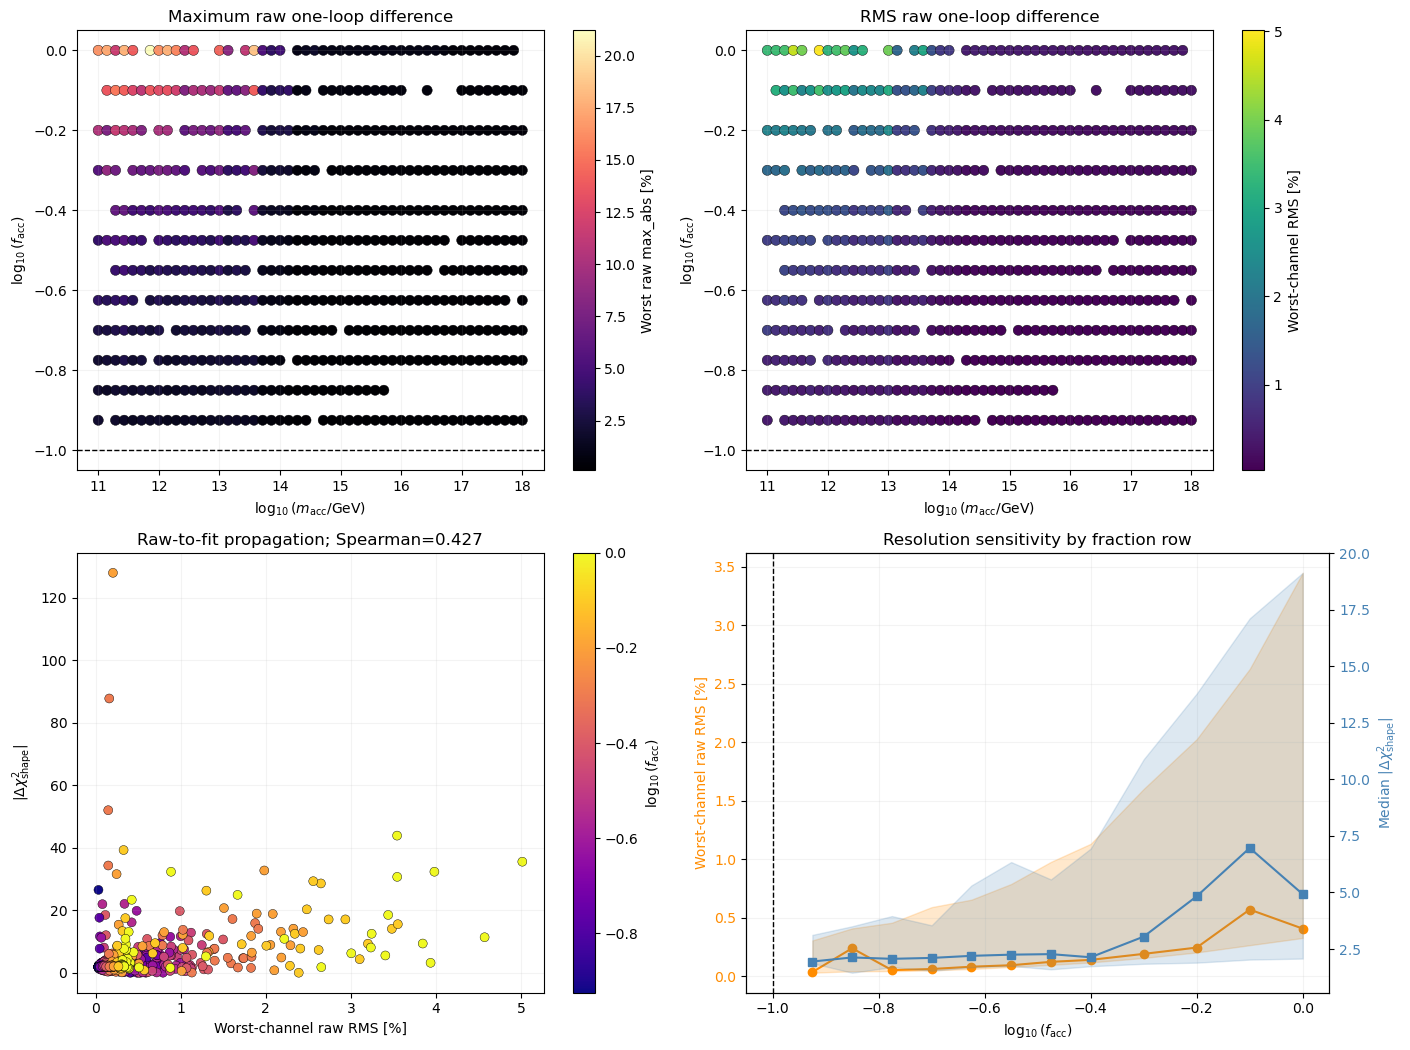

Nearest directly compared high-f row to f_acc=0.1
  log10(f_acc) = -0.925
  f_acc        = 0.11885
  points       = 48
  median RMS   = 0.0375%


In [8]:
fig_raw = None
raw_fit_overlap = pd.DataFrame()
if not raw_summary.empty:
    if not overlap.empty:
        raw_fit_overlap = overlap.merge(
            raw_summary[[
                "coordinate_key", "raw_max_abs", "raw_rms_max", "raw_rms_median",
                "worst_z", "worst_channel",
            ]],
            on="coordinate_key", how="inner", validate="one_to_one",
        )

    fig_raw, axes = plt.subplots(2, 2, figsize=(14.2, 10.6))
    map_max = axes[0, 0].scatter(
        raw_summary["log10m_acc"], raw_summary["log10f_acc"],
        c=100 * raw_summary["raw_max_abs"], cmap="magma", s=54,
        edgecolor="black", linewidth=0.3,
    )
    fig_raw.colorbar(map_max, ax=axes[0, 0], label="Worst raw max_abs [%]")
    axes[0, 0].set_title("Maximum raw one-loop difference")

    map_rms = axes[0, 1].scatter(
        raw_summary["log10m_acc"], raw_summary["log10f_acc"],
        c=100 * raw_summary["raw_rms_max"], cmap="viridis", s=54,
        edgecolor="black", linewidth=0.3,
    )
    fig_raw.colorbar(map_rms, ax=axes[0, 1], label="Worst-channel RMS [%]")
    axes[0, 1].set_title("RMS raw one-loop difference")

    if raw_fit_overlap.empty:
        axes[1, 0].text(0.5, 0.5, "No common completed fits yet", ha="center", va="center")
        axes[1, 0].set_axis_off()
    else:
        raw_shape_rank = spearmanr(
            raw_fit_overlap["raw_rms_max"], raw_fit_overlap["absolute_shape_shift"],
        )
        relation = axes[1, 0].scatter(
            100 * raw_fit_overlap["raw_rms_max"],
            raw_fit_overlap["absolute_shape_shift"],
            c=raw_fit_overlap["log10f_acc"], cmap="plasma", s=42,
            edgecolor="black", linewidth=0.3,
        )
        fig_raw.colorbar(relation, ax=axes[1, 0], label=r"$\log_{10}(f_{\rm acc})$")
        axes[1, 0].set_xlabel("Worst-channel raw RMS [%]")
        axes[1, 0].set_ylabel(r"$|\Delta\chi^2_{\rm shape}|$")
        axes[1, 0].set_title(f"Raw-to-fit propagation; Spearman={raw_shape_rank.statistic:.3f}")

    raw_rows = raw_summary.groupby("log10f_acc").agg(
        raw_median=("raw_rms_max", "median"),
        raw_q16=("raw_rms_max", lambda values: values.quantile(0.16)),
        raw_q84=("raw_rms_max", lambda values: values.quantile(0.84)),
        points=("coordinate_key", "size"),
    ).reset_index().sort_values("log10f_acc")
    axis_raw = axes[1, 1]
    axis_raw.plot(
        raw_rows["log10f_acc"], 100 * raw_rows["raw_median"],
        marker="o", color="darkorange", label="raw RMS median",
    )
    axis_raw.fill_between(
        raw_rows["log10f_acc"], 100 * raw_rows["raw_q16"], 100 * raw_rows["raw_q84"],
        color="darkorange", alpha=0.2,
    )
    axis_raw.set_xlabel(r"$\log_{10}(f_{\rm acc})$")
    axis_raw.set_ylabel("Worst-channel raw RMS [%]", color="darkorange")
    axis_raw.tick_params(axis="y", labelcolor="darkorange")
    if not overlap.empty:
        chi_rows = overlap.groupby("log10f_acc").agg(
            chi_median=("absolute_shape_shift", "median"),
            chi_q16=("absolute_shape_shift", lambda values: values.quantile(0.16)),
            chi_q84=("absolute_shape_shift", lambda values: values.quantile(0.84)),
        ).reset_index().sort_values("log10f_acc")
        axis_chi = axis_raw.twinx()
        axis_chi.plot(
            chi_rows["log10f_acc"], chi_rows["chi_median"],
            marker="s", color="steelblue", label=r"median $|\Delta\chi^2_{shape}|$",
        )
        axis_chi.fill_between(
            chi_rows["log10f_acc"], chi_rows["chi_q16"], chi_rows["chi_q84"],
            color="steelblue", alpha=0.18,
        )
        axis_chi.set_ylabel(r"Median $|\Delta\chi^2_{\rm shape}|$", color="steelblue")
        axis_chi.tick_params(axis="y", labelcolor="steelblue")
    axis_raw.axvline(TRANSITION_LOGF, color="black", ls="--", lw=1)
    axis_raw.set_title("Resolution sensitivity by fraction row")

    for axis in axes[0, :]:
        axis.axhline(TRANSITION_LOGF, color="black", ls="--", lw=1)
        axis.set_xlabel(r"$\log_{10}(m_{\rm acc}/{\rm GeV})$")
        axis.set_ylabel(r"$\log_{10}(f_{\rm acc})$")
    for axis in axes.ravel():
        axis.grid(alpha=0.14)
    fig_raw.tight_layout()
    plt.show()

    nearest_raw_row = raw_rows.iloc[(raw_rows["log10f_acc"] - TRANSITION_LOGF).abs().argmin()]
    print("Nearest directly compared high-f row to f_acc=0.1")
    print(f"  log10(f_acc) = {nearest_raw_row['log10f_acc']:.6g}")
    print(f"  f_acc        = {10**nearest_raw_row['log10f_acc']:.6g}")
    print(f"  points       = {int(nearest_raw_row['points'])}")
    print(f"  median RMS   = {100*nearest_raw_row['raw_median']:.4g}%")

## Nuisance-parameter response and bound audit

This separates a genuine theory-resolution effect from an imperfect fit. A
large raw spectral change with a stable refit is numerical theory sensitivity;
a large $\chi^2$ change with very small raw change, unstable nuisance shifts,
or proximity to a parameter bound is a refit candidate.

,points,median_absolute_shift,maximum_absolute_shift,median_normalized_box_shift,maximum_normalized_box_shift
parameter,,,,,
beta_ct,546,6.853639,1421.848829,0.008209,3.297325
beta_bias,546,0.027334,21.969134,0.000781,0.627690
alpha_bias,546,0.008802,5.635719,0.000550,0.352232
beta_F,546,0.012545,1.713244,0.000418,0.057108
log_alpha_F,546,0.001867,0.462684,0.000153,0.037906
alpha_ct,546,0.001873,0.453881,0.000002,0.002064


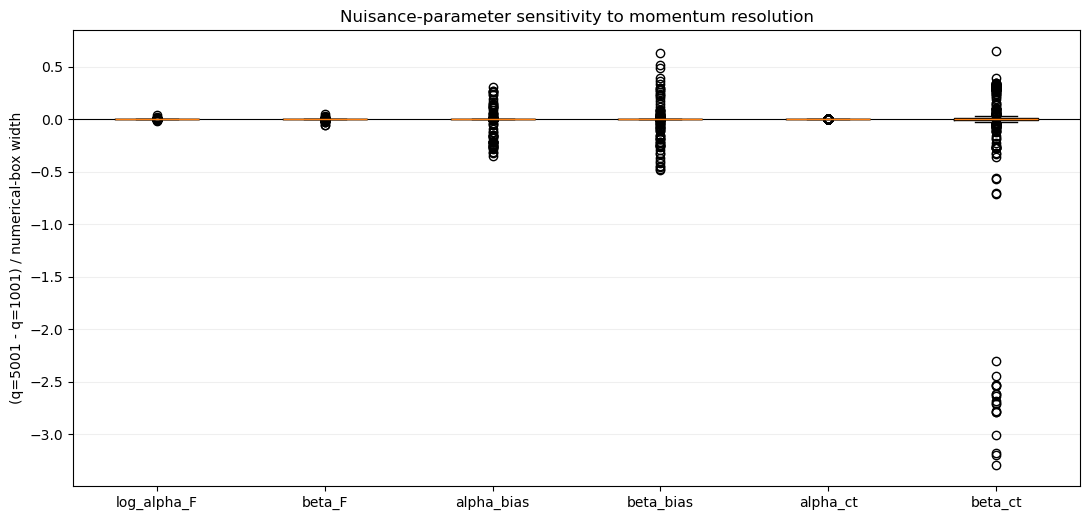

Completed points within 5% of a nuisance bound: 26


,point_id,log10m_acc,log10f_acc,source_label,momentum_bins,chi2_one_loop,delta_chi2_from_hybrid_minimum,inside_95pct,minimum_bound_parameter,minimum_bound_distance,within_5pct
1344,accdm_logm17p2857142857143_logfm0p2,17.285714,-0.200,high_q5001_recovery_10core,5001.0,194.401223,5.971625,True,beta_bias,0.000000e+00,True
1393,accdm_logm17p1428571428571_logfm0p1,17.142857,-0.100,high_q5001_recovery_10core,5001.0,202.987163,14.557565,False,beta_bias,0.000000e+00,True
1395,accdm_logm17p4285714285714_logfm0p1,17.428571,-0.100,high_q5001_original,5001.0,196.178580,7.748982,False,beta_bias,0.000000e+00,True
1293,accdm_logm17p1428571428571_logfm0p3,17.142857,-0.300,high_q5001_recovery_10core,5001.0,194.352828,5.923230,True,beta_bias,0.000000e+00,True
1343,accdm_logm17p1428571428571_logfm0p2,17.142857,-0.200,high_q5001_recovery_10core,5001.0,197.520048,9.090450,False,beta_bias,0.000000e+00,True
1342,accdm_logm17_logfm0p2,17.000000,-0.200,high_q5001_recovery_10core,5001.0,207.243726,18.814128,False,beta_bias,0.000000e+00,True
1286,accdm_logm16p1428571428571_logfm0p3,16.142857,-0.300,high_q5001_recovery_10core,5001.0,450.467397,262.037800,False,beta_bias,0.000000e+00,True
1291,accdm_logm16p8571428571429_logfm0p3,16.857143,-0.300,high_q5001_recovery_10core,5001.0,213.883810,25.454213,False,beta_bias,0.000000e+00,True
1446,accdm_logm17p5714285714286_logf0,17.571429,0.000,high_q5001_original,5001.0,198.235419,9.805821,False,beta_bias,0.000000e+00,True
1444,accdm_logm17p2857142857143_logf0,17.285714,0.000,high_q5001_recovery_10core,5001.0,201.045479,12.615881,False,beta_bias,0.000000e+00,True


In [9]:
PARAMETER_NAMES = [
    "log_alpha_F", "beta_F", "alpha_bias", "beta_bias", "alpha_ct", "beta_ct",
]
parameter_shifts = pd.DataFrame()
parameter_summary = pd.DataFrame()
fig_parameters = None

if not overlap.empty:
    rows = []
    for record in overlap.to_dict(orient="records"):
        for parameter in PARAMETER_NAMES:
            left_name = f"parameter_{parameter}_q1001"
            right_name = f"parameter_{parameter}_q5001"
            width_name = f"parameter_box_width_{parameter}_q5001"
            if left_name not in record or right_name not in record:
                continue
            left = float(record[left_name])
            right = float(record[right_name])
            width = float(record.get(width_name, np.nan))
            rows.append({
                "coordinate_key": record["coordinate_key"],
                "log10m_acc": record["log10m_acc"],
                "log10f_acc": record["log10f_acc"],
                "parameter": parameter,
                "value_q1001": left,
                "value_q5001": right,
                "absolute_shift": right - left,
                "box_width": width,
                "normalized_box_shift": (right - left) / width if width > 0 else np.nan,
            })
    parameter_shifts = pd.DataFrame(rows)

if not parameter_shifts.empty:
    parameter_summary = parameter_shifts.groupby("parameter").agg(
        points=("coordinate_key", "nunique"),
        median_absolute_shift=("absolute_shift", lambda values: float(np.median(np.abs(values)))),
        maximum_absolute_shift=("absolute_shift", lambda values: float(np.max(np.abs(values)))),
        median_normalized_box_shift=("normalized_box_shift", lambda values: float(np.nanmedian(np.abs(values)))),
        maximum_normalized_box_shift=("normalized_box_shift", lambda values: float(np.nanmax(np.abs(values)))),
    ).sort_values("maximum_normalized_box_shift", ascending=False)
    display(parameter_summary)

    fig_parameters, axis = plt.subplots(figsize=(11.0, 5.3))
    groups = [
        parameter_shifts.loc[
            parameter_shifts["parameter"] == name, "normalized_box_shift"
        ].dropna()
        for name in PARAMETER_NAMES
    ]
    axis.boxplot(groups, tick_labels=PARAMETER_NAMES, showfliers=True)
    axis.axhline(0, color="black", lw=0.8)
    axis.set_ylabel("(q=5001 - q=1001) / numerical-box width")
    axis.set_title("Nuisance-parameter sensitivity to momentum resolution")
    axis.grid(axis="y", alpha=0.2)
    fig_parameters.tight_layout()
    plt.show()

bound_audit = completed[[
    column for column in [
        "point_id", "log10m_acc", "log10f_acc", "source_label", "momentum_bins",
        "chi2_one_loop", "delta_chi2_from_hybrid_minimum", "inside_95pct",
        "minimum_bound_parameter", "minimum_bound_distance",
    ] if column in completed
]].copy()
if "minimum_bound_distance" in bound_audit:
    bound_audit["within_5pct"] = bound_audit["minimum_bound_distance"] <= BOUNDARY_FRACTION
    warnings_inside = bound_audit.loc[bound_audit["inside_95pct"] & bound_audit["within_5pct"]] \
        if "inside_95pct" in bound_audit else pd.DataFrame()
    print("Completed points within 5% of a nuisance bound:", int(bound_audit["within_5pct"].sum()))
    display(bound_audit.sort_values("minimum_bound_distance").head(30))

## Effective DCDM-coordinate view

For visual comparison only, the accDM energy gain is momentum-matched to the
massive daughter of a two-body DCDM decay. The fraction is mapped to an
effective rate by $f_{\rm acc}=1-e^{-\Gamma_{\rm eff}t_{\rm ref}}$ with
$t_{\rm ref}=14\,$Gyr. This is not an exact physical equivalence of the two
models.

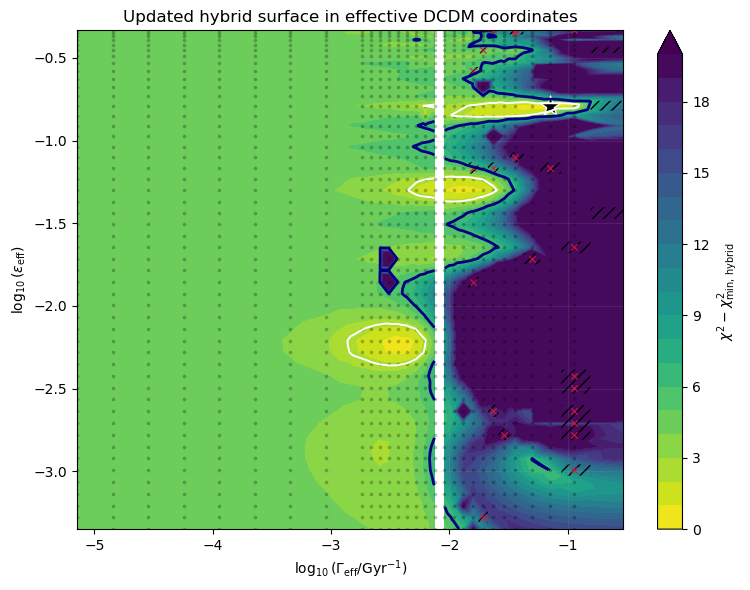

In [10]:
def eta_from_log10_mass(log10m_acc):
    return 10.0 ** (11.0 - np.asarray(log10m_acc, dtype=float))


def epsilon_effective_from_log10_mass(log10m_acc):
    eta = eta_from_log10_mass(log10m_acc)
    recoil = np.sqrt(eta * (eta + 2.0))
    return recoil / (np.sqrt(1.0 + recoil**2) + recoil)


def gamma_effective_from_log10_fraction(log10f_acc, t_reference_gyr=T_REFERENCE_GYR):
    fraction = 10.0 ** np.asarray(log10f_acc, dtype=float)
    gamma = np.full_like(fraction, np.inf, dtype=float)
    finite = fraction < 1.0
    gamma[finite] = -np.log1p(-fraction[finite]) / float(t_reference_gyr)
    return gamma


epsilon_dense = epsilon_effective_from_log10_mass(x_dense)
gamma_dense = gamma_effective_from_log10_fraction(y_dense)
finite_gamma_rows = np.isfinite(gamma_dense) & (gamma_dense > 0)
log_gamma_dense = np.log10(gamma_dense[finite_gamma_rows])
log_epsilon_dense = np.log10(epsilon_dense[::-1])

def dcdm_orientation(surface):
    return np.ma.asarray(surface)[finite_gamma_rows, ::-1].T

delta_dcdm = dcdm_orientation(delta_min_bracketed)
unsupported_dcdm = unsupported[finite_gamma_rows, ::-1].T
point_epsilon = np.log10(epsilon_effective_from_log10_mass(completed["log10m_acc"]))
point_gamma = np.log10(gamma_effective_from_log10_fraction(completed["log10f_acc"]))
missing_epsilon = np.log10(epsilon_effective_from_log10_mass(missing["log10m_acc"]))
missing_gamma = np.log10(gamma_effective_from_log10_fraction(missing["log10f_acc"]))
best_epsilon = float(np.log10(epsilon_effective_from_log10_mass([best["log10m_acc"]]))[0])
best_gamma = float(np.log10(gamma_effective_from_log10_fraction([best["log10f_acc"]]))[0])

fig_dcdm, axis = plt.subplots(figsize=(7.8, 6.0))
plotted = axis.contourf(
    log_gamma_dense, log_epsilon_dense, np.clip(delta_dcdm, 0, DISPLAY_DELTA_MAX),
    levels=np.linspace(0, DISPLAY_DELTA_MAX, 21), cmap="viridis_r", extend="max",
)
axis.contour(
    log_gamma_dense, log_epsilon_dense, delta_dcdm,
    levels=[DELTA_CHI2_68_2D, DELTA_CHI2_95_2D],
    colors=["white", "navy"], linewidths=[1.4, 2.0],
)
axis.contourf(
    log_gamma_dense, log_epsilon_dense, unsupported_dcdm.astype(float),
    levels=[0.5, 1.5], colors="none", hatches=["///"], alpha=0,
)
finite_points = np.isfinite(point_gamma)
finite_missing = np.isfinite(missing_gamma)
axis.scatter(point_gamma[finite_points], point_epsilon[finite_points], s=3, color="black", alpha=0.18)
axis.scatter(
    missing_gamma[finite_missing], missing_epsilon[finite_missing], marker="x", s=21,
    color="crimson", linewidth=0.75,
)
if np.isfinite(best_gamma):
    axis.scatter([best_gamma], [best_epsilon], marker="*", s=235, color="black", edgecolor="white")
axis.set_xlabel(r"$\log_{10}(\Gamma_{\rm eff}/{\rm Gyr}^{-1})$")
axis.set_ylabel(r"$\log_{10}(\epsilon_{\rm eff})$")
axis.set_title("Updated hybrid surface in effective DCDM coordinates")
axis.grid(alpha=0.12)
fig_dcdm.colorbar(plotted, ax=axis, label=r"$\chi^2-\chi^2_{\min,\,\mathrm{hybrid}}$")
fig_dcdm.tight_layout()
plt.show()

## Save analysis products

The exported tables retain source labels and momentum-bin counts, so the
hybrid construction can be audited later. Re-run the notebook after further
theory and fit jobs finish; newly available q=5001 points will automatically
replace crosses and extend the cached raw comparison.

In [11]:
if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    completed.sort_values(["log10f_acc", "log10m_acc"]).to_csv(
        OUTPUT_DIR / "updated_hybrid_sampled_profile_likelihood.csv", index=False,
    )
    missing.sort_values(["log10f_acc", "log10m_acc"]).to_csv(
        OUTPUT_DIR / "updated_hybrid_cross_markers.csv", index=False,
    )
    if not overlap.empty:
        overlap.sort_values(["log10f_acc", "log10m_acc"]).to_csv(
            OUTPUT_DIR / "updated_highf_q1001_q5001_fit_overlap.csv", index=False,
        )
    if not raw_fit_overlap.empty:
        raw_fit_overlap.sort_values(["log10f_acc", "log10m_acc"]).to_csv(
            OUTPUT_DIR / "updated_raw_to_fit_overlap.csv", index=False,
        )
    if not parameter_shifts.empty:
        parameter_shifts.to_csv(
            OUTPUT_DIR / "updated_highf_q1001_q5001_parameter_shifts.csv", index=False,
        )
        parameter_summary.to_csv(
            OUTPUT_DIR / "updated_highf_q1001_q5001_parameter_summary.csv",
        )
    bound_audit.to_csv(OUTPUT_DIR / "updated_nuisance_bound_audit.csv", index=False)

    summary = {
        "scope": "low_q1001_with_targeted_q2501_plus_all_completed_high_q5001_recoveries",
        "resolution_transition_log10f": float(TRANSITION_LOGF),
        "expected_points": int(len(expected)),
        "completed_points": int(len(completed)),
        "cross_markers": int(len(missing)),
        "selected_counts": {
            str(key): int(value)
            for key, value in completed["source_label"].value_counts().items()
        },
        "lcdm_reference_chi2": float(LCDM_ONE_LOOP_CHI2),
        "sampled_best_point": {
            "point_id": str(best.get("point_id", best["coordinate_key"])),
            "log10m_acc": float(best["log10m_acc"]),
            "log10f_acc": float(best["log10f_acc"]),
            "chi2_one_loop": float(best["chi2_one_loop"]),
            "delta_chi2_vs_lcdm": float(best["delta_chi2_vs_lcdm"]),
            "source_label": str(best["source_label"]),
            "momentum_bins": int(best["momentum_bins"]),
        },
        "fit_overlap_points": int(len(overlap)),
        "raw_theory_overlap_points": int(len(raw_summary)),
        "raw_compare_kmax_hmpc": float(RAW_COMPARE_KMAX),
        "warnings": [
            "pending_failed_and_unfitted_expected_points_are_common_crosses",
            "interpolation_is_separate_across_f_acc_0p1_resolution_transition",
            "high_fraction_q1001_is_diagnostic_only",
            "edge_bracketed_hatching_is_visualization_only",
            "effective_dcdm_coordinates_are_not_an_exact_model_equivalence",
        ],
    }
    if not overlap.empty:
        summary["fit_overlap_summary"] = {
            key: (int(value) if key in {
                "overlap points", "changed 68% classifications", "changed 95% classifications",
            } else float(value))
            for key, value in overlap_summary.items()
        }
    if not raw_summary.empty:
        summary["raw_theory_summary"] = {
            "median_raw_max_abs": float(raw_summary["raw_max_abs"].median()),
            "maximum_raw_max_abs": float(raw_summary["raw_max_abs"].max()),
            "median_raw_rms_max": float(raw_summary["raw_rms_max"].median()),
            "maximum_raw_rms_max": float(raw_summary["raw_rms_max"].max()),
        }
    (OUTPUT_DIR / "updated_hybrid_analysis_summary.json").write_text(
        json.dumps(summary, indent=2, sort_keys=True) + "\n", encoding="utf-8",
    )

    fig_coverage.savefig(
        OUTPUT_DIR / "updated_hybrid_sampled_likelihood_and_coverage.png",
        dpi=220, bbox_inches="tight",
    )
    fig_profile.savefig(
        OUTPUT_DIR / "updated_hybrid_profile_likelihood.png",
        dpi=220, bbox_inches="tight",
    )
    if "fig_chi2" in globals():
        fig_chi2.savefig(
            OUTPUT_DIR / "updated_highf_q1001_q5001_chi2_diagnostics.png",
            dpi=220, bbox_inches="tight",
        )
    if fig_raw is not None:
        fig_raw.savefig(
            OUTPUT_DIR / "updated_highf_q1001_q5001_raw_theory_diagnostics.png",
            dpi=220, bbox_inches="tight",
        )
    if fig_parameters is not None:
        fig_parameters.savefig(
            OUTPUT_DIR / "updated_highf_q1001_q5001_nuisance_shifts.png",
            dpi=220, bbox_inches="tight",
        )
    fig_dcdm.savefig(
        OUTPUT_DIR / "updated_hybrid_effective_dcdm_coordinates.png",
        dpi=220, bbox_inches="tight",
    )
    print("Saved products to:", OUTPUT_DIR)

Saved products to: /home/2/ks405818/Master/lyalpha_one_loop/runs/accdm/analysis_updated_hybrid_q1001_q5001_recovery_v1


## Interpretation checklist

1. Use the sampled minimum for every numerical claim; contours are visual.
2. Treat the high-f map as incomplete until crosses near a relevant contour or
   minimum have been recovered.
3. Inspect both absolute $\Delta\chi^2$ and subset-normalized shape shifts.
4. Use raw one-loop RMS/max differences to distinguish theory-resolution
   sensitivity from nuisance-fit behavior.
5. Points with small raw differences but large $\chi^2$ or nuisance shifts are
   cross-refit candidates.
6. The nearest directly compared high-f row is above, not exactly on,
   $f_{\rm acc}=0.1$; the notebook never claims an exact boundary comparison.
7. Final contours still require targeted convergence checks near the resulting
   minimum and confidence boundary.